# RoBERTa - BANKING77 Intent Classification

This project fine-tunes the pretrained `roberta-base` model for 77-class intent classification on the BANKING77 dataset. The workflow uses the provided training and test splits, creates a stratified validation split from training data, selects the best checkpoint using validation macro F1, and evaluates the final model with class-level, confusion, confidence, and error analysis.

## 1. Import Required Libraries

Load the libraries needed for dataset loading, tokenization, RoBERTa fine-tuning, evaluation, visualization, and reproducibility.

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset, Dataset
from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4


## 2. Load the BANKING77 Dataset

Load the dataset and inspect its splits and 77 intent labels.

In [2]:
from datasets import Dataset, DatasetDict

train_url = (
    "https://raw.githubusercontent.com/"
    "PolyAI-LDN/task-specific-datasets/"
    "master/banking_data/train.csv"
)

test_url = (
    "https://raw.githubusercontent.com/"
    "PolyAI-LDN/task-specific-datasets/"
    "master/banking_data/test.csv"
)

train_df = pd.read_csv(
    train_url
)

test_df = pd.read_csv(
    test_url
)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

print("\nTrain Columns:")
print(train_df.columns.tolist())

print("\nTest Columns:")
print(test_df.columns.tolist())

print("\nFirst Training Example:")
print(train_df.head(1))

# The CSVs contain the banking query and its intent label.
# Convert the text labels into a stable integer mapping.
class_names = sorted(
    train_df["category"].unique()
)

label_to_id = {
    label: index
    for index, label in enumerate(class_names)
}

id_to_label = {
    index: label
    for label, index in label_to_id.items()
}

train_df["label"] = train_df["category"].map(
    label_to_id
)

test_df["label"] = test_df["category"].map(
    label_to_id
)

train_df = train_df[
    ["text", "label"]
].copy()

test_df = test_df[
    ["text", "label"]
].copy()

dataset = DatasetDict({
    "train": Dataset.from_pandas(
        train_df,
        preserve_index=False
    ),
    "test": Dataset.from_pandas(
        test_df,
        preserve_index=False
    )
})

print("\nDataset:")
print(dataset)

print(
    "\nNumber of Intent Classes:",
    len(class_names)
)

print("\nIntent Classes:")
for index, class_name in enumerate(class_names):
    print(
        f"{index:2d}: {class_name}"
    )

Train Shape: (10003, 2)
Test Shape: (3080, 2)

Train Columns:
['text', 'category']

Test Columns:
['text', 'category']

First Training Example:
                             text      category
0  I am still waiting on my card?  card_arrival

Dataset:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})

Number of Intent Classes: 77

Intent Classes:
 0: Refund_not_showing_up
 1: activate_my_card
 2: age_limit
 3: apple_pay_or_google_pay
 4: atm_support
 5: automatic_top_up
 6: balance_not_updated_after_bank_transfer
 7: balance_not_updated_after_cheque_or_cash_deposit
 8: beneficiary_not_allowed
 9: cancel_transfer
10: card_about_to_expire
11: card_acceptance
12: card_arrival
13: card_delivery_estimate
14: card_linking
15: card_not_working
16: card_payment_fee_charged
17: card_payment_not_recognised
18: card_payment_wrong_exchange_rate
19: card_swall

## 3. Create Stratified Train and Validation Splits

Keep the official test split untouched and create a stratified validation set from training data.

In [3]:
train_texts = np.array(
    dataset["train"]["text"],
    dtype=object
)

train_labels = np.array(
    dataset["train"]["label"],
    dtype=np.int64
)

test_texts = np.array(
    dataset["test"]["text"],
    dtype=object
)

test_labels = np.array(
    dataset["test"]["label"],
    dtype=np.int64
)

train_texts, val_texts, train_labels, val_labels = (
    train_test_split(
        train_texts,
        train_labels,
        test_size=0.10,
        random_state=SEED,
        stratify=train_labels
    )
)

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))

print(
    "\nTraining Distribution:",
    np.bincount(
        train_labels,
        minlength=len(class_names)
    )
)

print(
    "\nValidation Distribution:",
    np.bincount(
        val_labels,
        minlength=len(class_names)
    )
)

print(
    "\nTest Distribution:",
    np.bincount(
        test_labels,
        minlength=len(class_names)
    )
)

Training Samples: 9002
Validation Samples: 1001
Test Samples: 3080

Training Distribution: [146 143  99 113  78 114 154 163 140 141 116  53 138 101 125 101 168 151
 150  55 159 144 110  77  32 116 138 156 120 164 109 109 109 101 106 149
 123 113  87  95 116  88  74 109 108  95 143 129 134 133 104  86 152 145
 116  97 100 103 103 130  87 131  93 157 155 102 154 115  92  94 102 113
  37 121 109 162 147]

Validation Distribution: [16 16 11 13  9 13 17 18 16 16 13  6 15 11 14 11 19 17 17  6 18 16 12  9
  3 13 15 17 13 18 12 12 12 11 12 17 14 13 10 11 13 10  8 12 12 10 16 14
 15 15 11  9 17 16 13 11 11 11 11 15 10 15 10 18 17 11 17 13 10 10 11 13
  4 14 12 18 16]

Test Distribution: [40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40
 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40
 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40
 40 40 40 40 40]


## 4. Explore the Dataset

Inspect the intent distribution and representative banking queries.

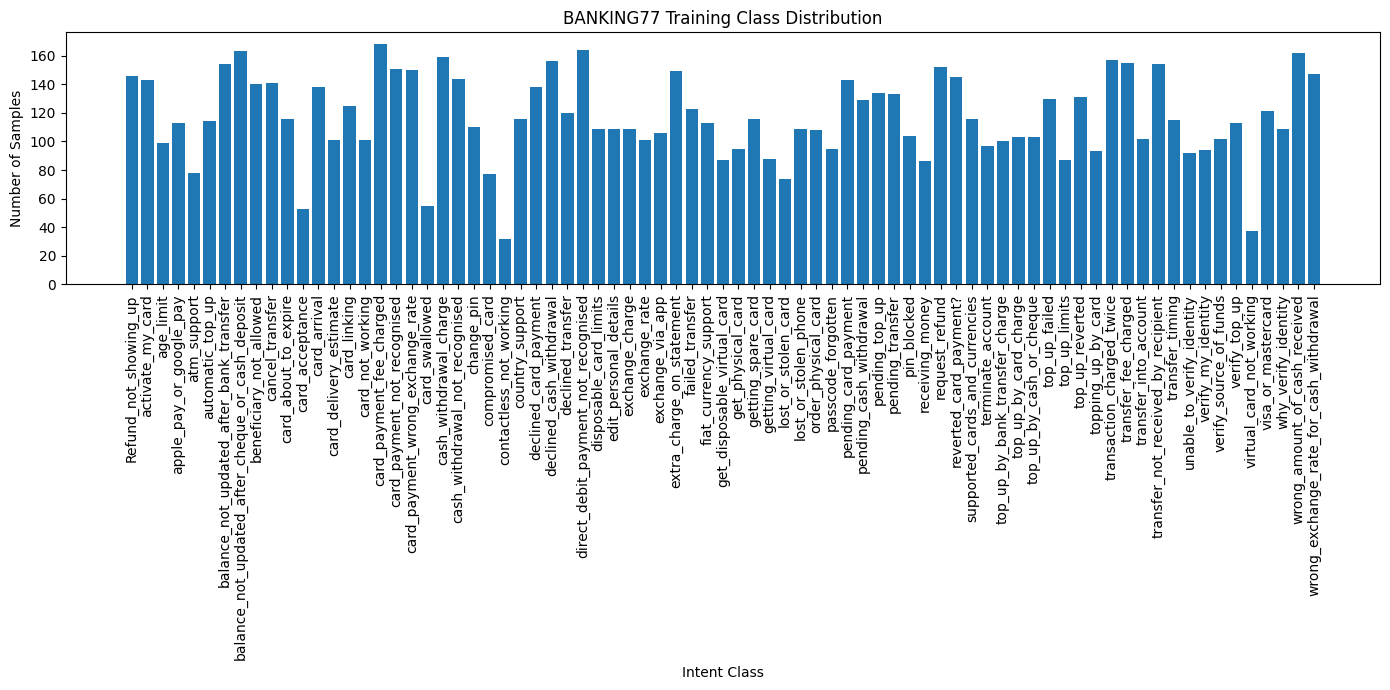

Intent: Refund_not_showing_up
- When will my returned transaction show up on my account?
- How do I find the refund on my statement?

Intent: activate_my_card
- I want to activate the card.
- how long should i wait ti activate my card

Intent: age_limit
- If I want my son to have his own account is that possible?
- What age do you have to be to open an account?

Intent: apple_pay_or_google_pay
- How do i top up my google pay?
- Am I able to top up with Apple Pay?

Intent: atm_support
- How far is the closest ATM from me?
- What's the closest place to withdraw money?

Intent: automatic_top_up
- If I am running low on credit can I auto top up?
- What is the maximum times I can auto top-up?

Intent: balance_not_updated_after_bank_transfer
- Can you tell me why the transfer isn't showing up on my account?
- I haven't yet received money that I transferred

Intent: balance_not_updated_after_cheque_or_cash_deposit
- Hi,  My money has not been credited to my account for which i have sent you c

In [4]:
train_counts = np.bincount(train_labels, minlength=len(class_names))

plt.figure(figsize=(14, 7))
plt.bar(range(len(class_names)), train_counts)
plt.xlabel("Intent Class")
plt.ylabel("Number of Samples")
plt.title("BANKING77 Training Class Distribution")
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.tight_layout()
plt.show()

for class_id, class_name in enumerate(class_names):
    indices = np.where(train_labels == class_id)[0]
    print("=" * 100)
    print("Intent:", class_name)
    for index in indices[:2]:
        print("-", train_texts[index])
    print()

## 5. Load the RoBERTa Tokenizer

Use the pretrained RoBERTa tokenizer.

In [5]:
model_name = "roberta-base"
max_length = 128

tokenizer = RobertaTokenizerFast.from_pretrained(model_name)

print("Model:", model_name)
print("Vocabulary Size:", tokenizer.vocab_size)
print("Maximum Sequence Length:", max_length)

sample = tokenizer(train_texts[0], truncation=True, padding="max_length", max_length=max_length)
print("Sample Token Count:", len(sample["input_ids"]))

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Model: roberta-base
Vocabulary Size: 50265
Maximum Sequence Length: 128
Sample Token Count: 128


## 6. Tokenize the Dataset

Tokenize training, validation, and test queries and prepare them for Trainer.

In [6]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_length
    )

train_dataset = Dataset.from_dict({
    "text": train_texts.tolist(),
    "label": train_labels.tolist()
})
val_dataset = Dataset.from_dict({
    "text": val_texts.tolist(),
    "label": val_labels.tolist()
})
test_dataset = Dataset.from_dict({
    "text": test_texts.tolist(),
    "label": test_labels.tolist()
})

train_dataset = train_dataset.map(tokenize_batch, batched=True)
val_dataset = val_dataset.map(tokenize_batch, batched=True)
test_dataset = test_dataset.map(tokenize_batch, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Map:   0%|          | 0/9002 [00:00<?, ? examples/s]

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 9002
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 1001
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 3080
})


## 7. Build the RoBERTa Intent Classifier

Load pretrained RoBERTa with a 77-class classification head.

In [7]:
model = RobertaForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(class_names),
    id2label={i: name for i, name in enumerate(class_names)},
    label2id={name: i for i, name in enumerate(class_names)}
)

print("Model:", model_name)
print("Number of Labels:", model.config.num_labels)
print("Trainable Parameters:", f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: roberta-base
Number of Labels: 77
Trainable Parameters: 124,704,845


## 8. Define Evaluation Metrics

Track accuracy, macro precision, recall, macro F1, and weighted F1.

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

## 9. Configure Fine-Tuning

Use Hugging Face Trainer with a conservative RoBERTa fine-tuning setup and validation macro F1 as the checkpoint-selection metric.

In [9]:
batch_size = 32
learning_rate = 2e-5
num_epochs = 30

training_args = TrainingArguments(
    output_dir="./roberta_banking77_results",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    learning_rate=learning_rate,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    data_seed=SEED,
    save_total_limit=2
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Batch Size:", batch_size)
print("Learning Rate:", learning_rate)
print("Maximum Epochs:", num_epochs)
print("Best Checkpoint Metric: Validation Macro F1")

Batch Size: 32
Learning Rate: 2e-05
Maximum Epochs: 30
Best Checkpoint Metric: Validation Macro F1


## 10. Fine-Tune RoBERTa

Train on the training split and evaluate on validation after each epoch.

In [10]:
train_result = trainer.train()

print("Training completed.")
print("Training Loss:", train_result.training_loss)
print("Best Checkpoint:", trainer.state.best_model_checkpoint)

if trainer.state.best_metric is not None:
    print(f"Best Validation Macro F1: {trainer.state.best_metric:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,4.068510,3.451630,0.171828,0.169151,0.157495,0.108190,0.189125,0.171828,0.118802
2,2.962413,2.271238,0.469530,0.532276,0.444896,0.408095,0.550111,0.469530,0.425742
3,2.088131,1.714392,0.602398,0.635457,0.583901,0.564505,0.645836,0.602398,0.579323
4,1.536943,1.272241,0.690310,0.693368,0.665610,0.653973,0.707108,0.690310,0.676581
5,1.189047,1.033264,0.747253,0.758051,0.736193,0.729433,0.761529,0.747253,0.739314
6,0.941124,0.878744,0.793207,0.817132,0.794234,0.790865,0.816176,0.793207,0.790048
7,0.761923,0.778019,0.803197,0.817273,0.798257,0.797401,0.816326,0.803197,0.801069
8,0.624601,0.737449,0.821179,0.840426,0.822093,0.821305,0.837230,0.821179,0.820100
9,0.528227,0.650369,0.835165,0.852030,0.837265,0.838711,0.847791,0.835165,0.836017
10,0.439121,0.616133,0.848152,0.858405,0.851124,0.850575,0.854893,0.848152,0.847279


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed.
Training Loss: 1.0394721090370882
Best Checkpoint: ./roberta_banking77_results/checkpoint-3948
Best Validation Macro F1: 0.8661


## 11. Training Curves

Visualize loss and validation performance.

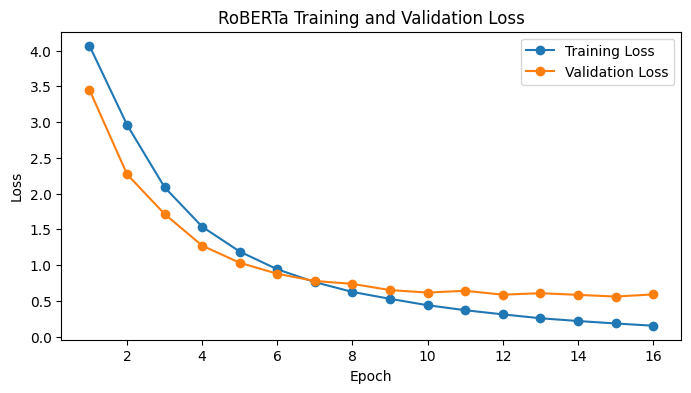

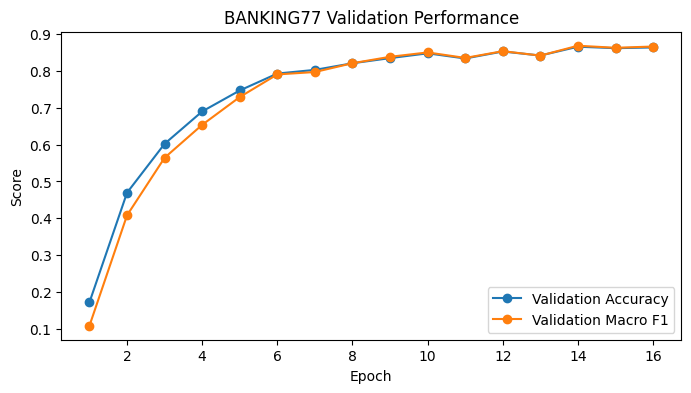

Best Epoch: 14
Best Validation Accuracy: 0.8661
Best Validation Macro F1: 0.8688


In [11]:
history = pd.DataFrame(trainer.state.log_history)
train_history = history[history["loss"].notna()].copy()
eval_history = history[history["eval_loss"].notna()].copy()

plt.figure(figsize=(8, 4))
plt.plot(train_history["epoch"], train_history["loss"], marker="o", label="Training Loss")
plt.plot(eval_history["epoch"], eval_history["eval_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RoBERTa Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(eval_history["epoch"], eval_history["eval_accuracy"], marker="o", label="Validation Accuracy")
plt.plot(eval_history["epoch"], eval_history["eval_macro_f1"], marker="o", label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("BANKING77 Validation Performance")
plt.legend()
plt.show()

best_row = eval_history.loc[eval_history["eval_macro_f1"].idxmax()]
print("Best Epoch:", int(best_row["epoch"]))
print(f"Best Validation Accuracy: {best_row['eval_accuracy']:.4f}")
print(f"Best Validation Macro F1: {best_row['eval_macro_f1']:.4f}")

## 12. Final Test Evaluation

Evaluate the restored best checkpoint exactly once on the untouched test set.

In [12]:
test_output = trainer.predict(test_dataset)
test_predictions = np.argmax(test_output.predictions, axis=-1)
test_labels_final = np.array(test_output.label_ids)

test_accuracy = accuracy_score(test_labels_final, test_predictions)
test_macro_precision, test_macro_recall, test_macro_f1, _ = precision_recall_fscore_support(
    test_labels_final, test_predictions, average="macro", zero_division=0
)
test_weighted_precision, test_weighted_recall, test_weighted_f1, _ = precision_recall_fscore_support(
    test_labels_final, test_predictions, average="weighted", zero_division=0
)

print(f"Test Loss: {test_output.metrics.get('test_loss', float('nan')):.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro Precision: {test_macro_precision:.4f}")
print(f"Test Macro Recall: {test_macro_recall:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print(f"Test Weighted F1: {test_weighted_f1:.4f}")

Test Loss: 0.5967
Test Accuracy: 0.8565
Test Macro Precision: 0.8671
Test Macro Recall: 0.8565
Test Macro F1: 0.8562
Test Weighted F1: 0.8562


## 13. Classification Report and Confusion Matrix

Inspect 77-intent class-level performance and common confusion patterns.

,precision,recall,f1-score,support
Refund_not_showing_up,0.878049,0.900000,0.888889,40.000000
activate_my_card,0.926829,0.950000,0.938272,40.000000
age_limit,0.975000,0.975000,0.975000,40.000000
apple_pay_or_google_pay,0.975610,1.000000,0.987654,40.000000
atm_support,0.975000,0.975000,0.975000,40.000000
...,...,...,...,...
wrong_amount_of_cash_received,0.888889,0.800000,0.842105,40.000000
wrong_exchange_rate_for_cash_withdrawal,0.909091,0.750000,0.821918,40.000000
accuracy,0.856494,0.856494,0.856494,0.856494
macro avg,0.867056,0.856494,0.856178,3080.000000


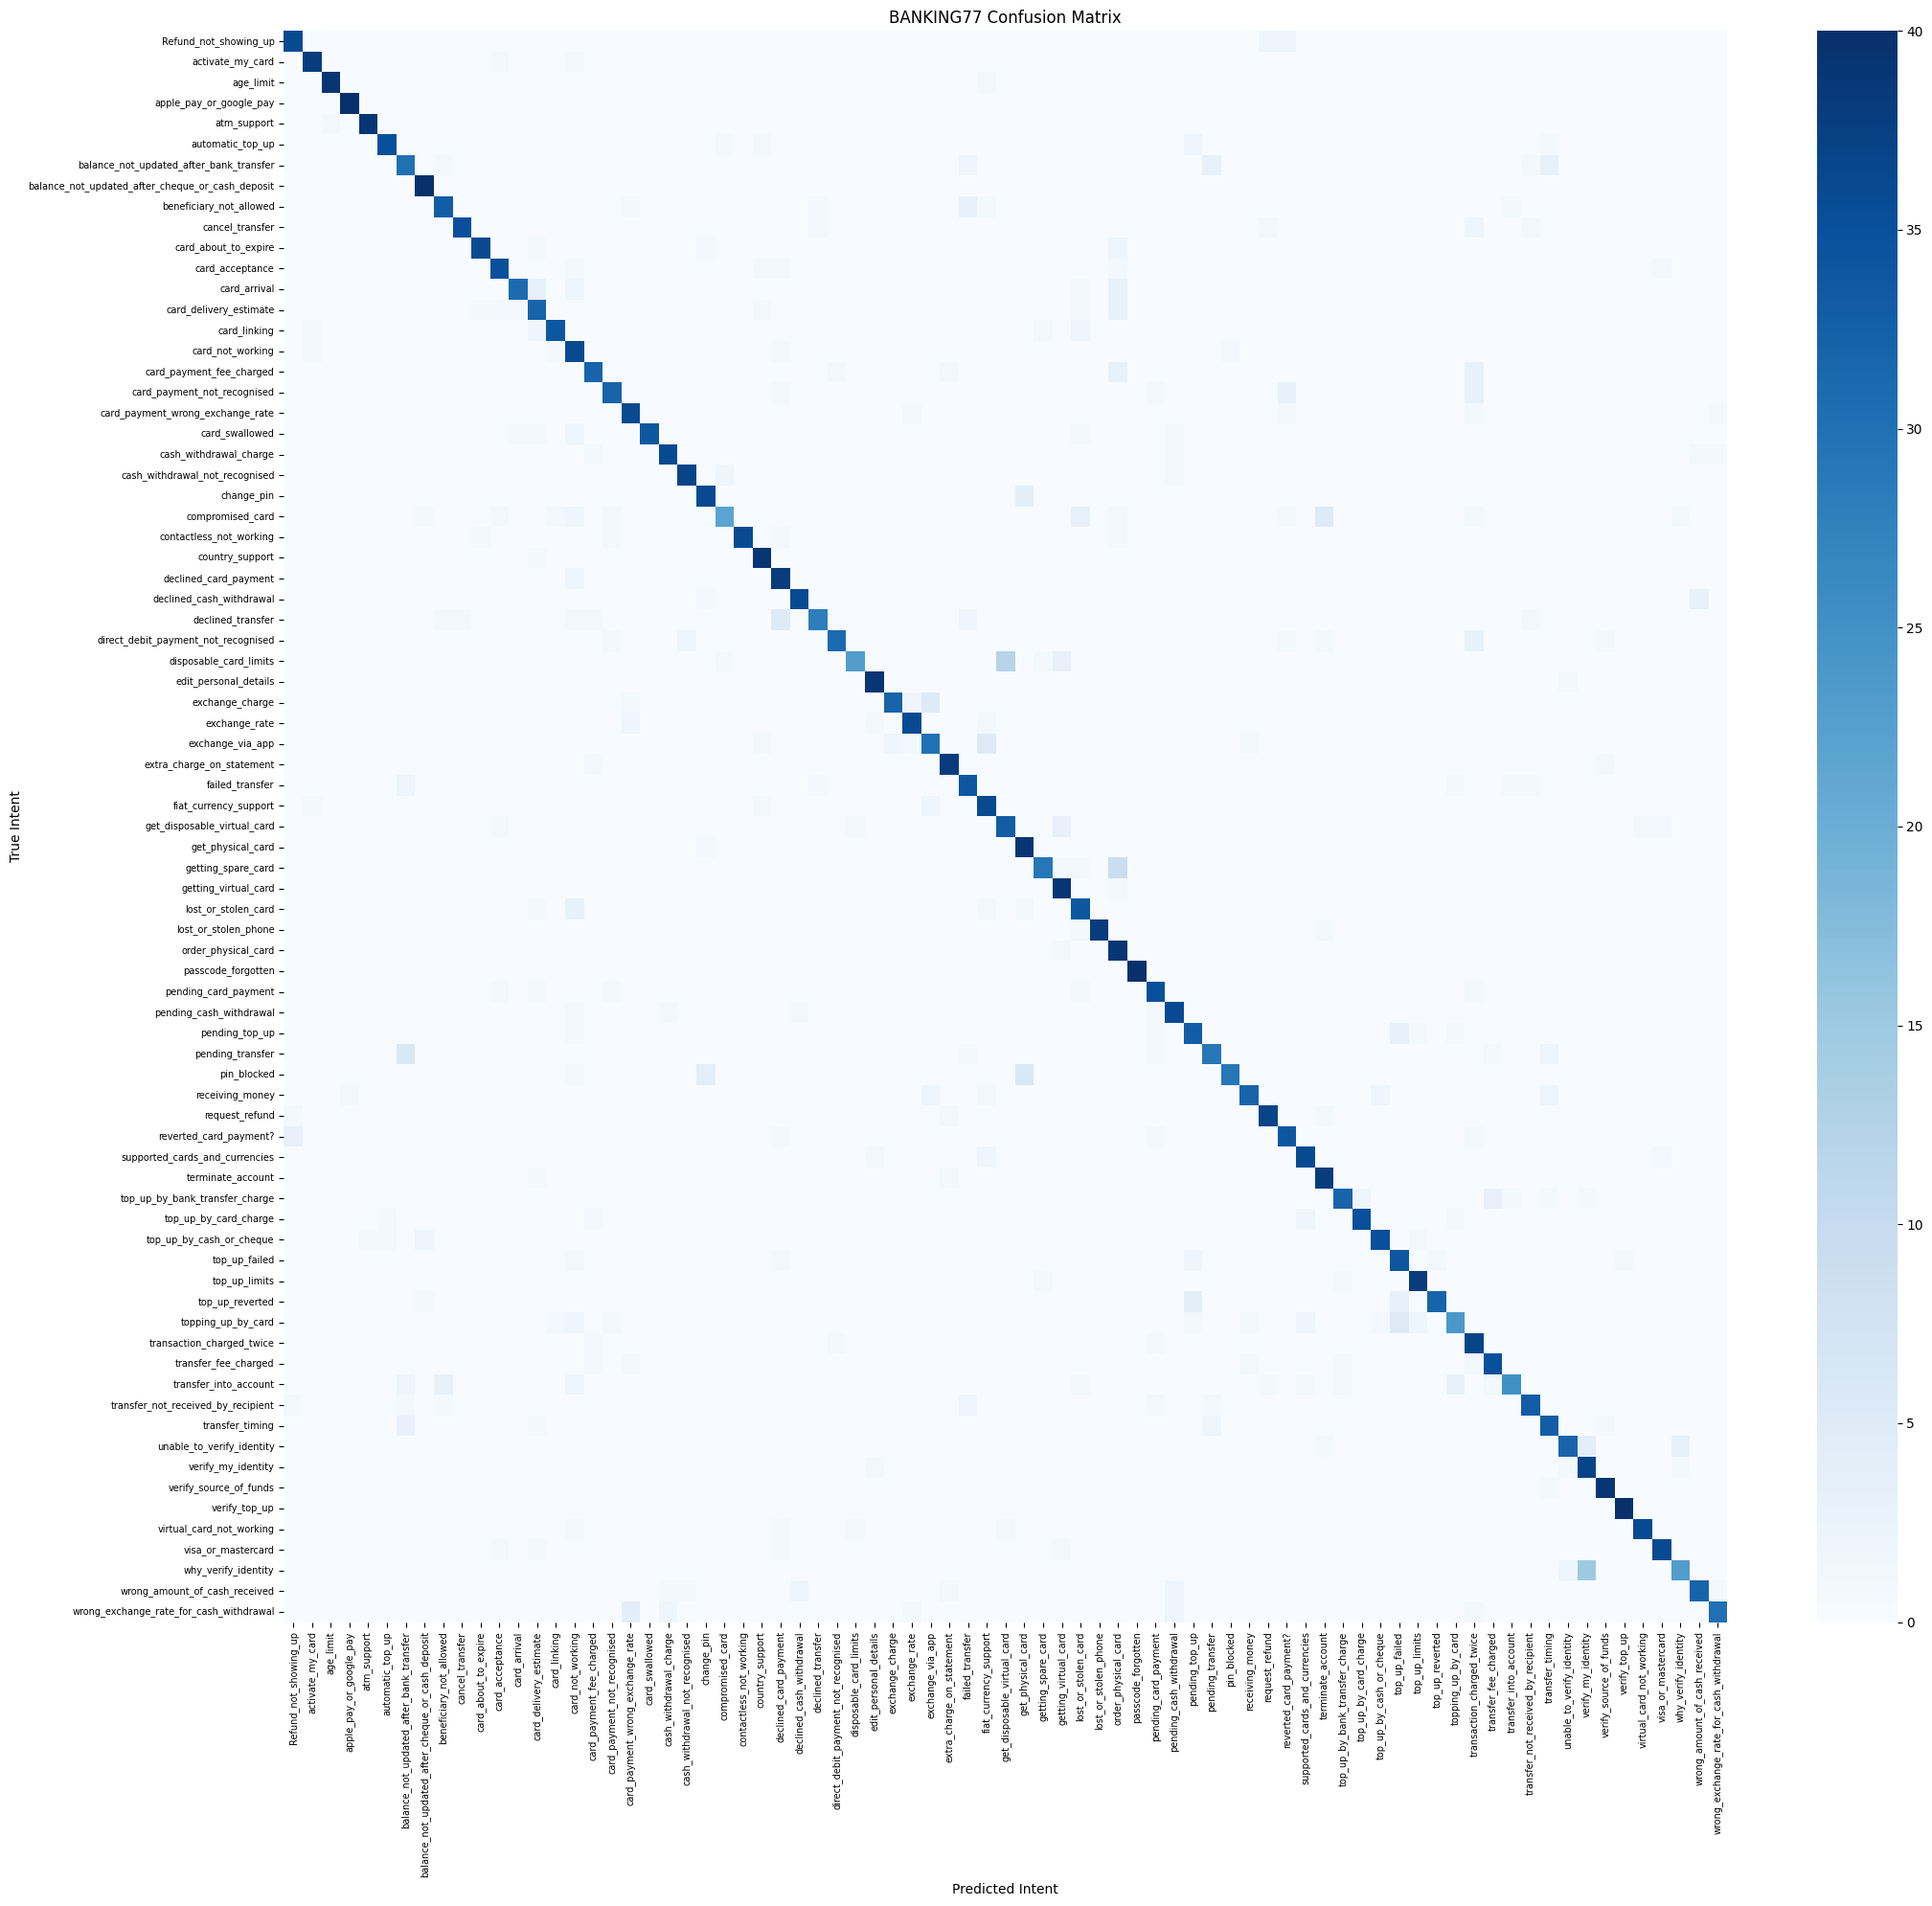

In [13]:
report = classification_report(
    test_labels_final,
    test_predictions,
    target_names=class_names,
    digits=4,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
display(report_df)

cm = confusion_matrix(test_labels_final, test_predictions)

plt.figure(figsize=(22, 20))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)
plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")
plt.title("BANKING77 Confusion Matrix")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

## 14. Per-Intent Performance Analysis

Rank the strongest and weakest intents by F1-score.

In [14]:
per_class_report = report_df.loc[
    class_names,
    ["precision", "recall", "f1-score", "support"]
].copy()

print("10 Lowest-F1 Intents")
display(per_class_report.sort_values("f1-score").head(10))

print("10 Highest-F1 Intents")
display(per_class_report.sort_values("f1-score", ascending=False).head(10))

10 Lowest-F1 Intents


,precision,recall,f1-score,support
compromised_card,0.846154,0.550,0.666667,40.0
why_verify_identity,0.821429,0.575,0.676471,40.0
topping_up_by_card,0.800000,0.600,0.685714,40.0
disposable_card_limits,0.920000,0.575,0.707692,40.0
balance_not_updated_after_bank_transfer,0.681818,0.750,0.714286,40.0
card_not_working,0.610169,0.900,0.727273,40.0
transfer_into_account,0.892857,0.625,0.735294,40.0
card_delivery_estimate,0.711111,0.800,0.752941,40.0
order_physical_card,0.619048,0.975,0.757282,40.0
exchange_via_app,0.769231,0.750,0.759494,40.0


10 Highest-F1 Intents


,precision,recall,f1-score,support
passcode_forgotten,1.000000,1.000,1.000000,40.0
verify_top_up,0.975610,1.000,0.987654,40.0
apple_pay_or_google_pay,0.975610,1.000,0.987654,40.0
atm_support,0.975000,0.975,0.975000,40.0
age_limit,0.975000,0.975,0.975000,40.0
lost_or_stolen_phone,1.000000,0.950,0.974359,40.0
balance_not_updated_after_cheque_or_cash_deposit,0.909091,1.000,0.952381,40.0
edit_personal_details,0.928571,0.975,0.951220,40.0
verify_source_of_funds,0.928571,0.975,0.951220,40.0
contactless_not_working,1.000000,0.900,0.947368,40.0


## 15. Confidence Analysis

Compare confidence for correct and incorrect predictions.

Mean Confidence - Correct: 0.9326
Mean Confidence - Incorrect: 0.7010


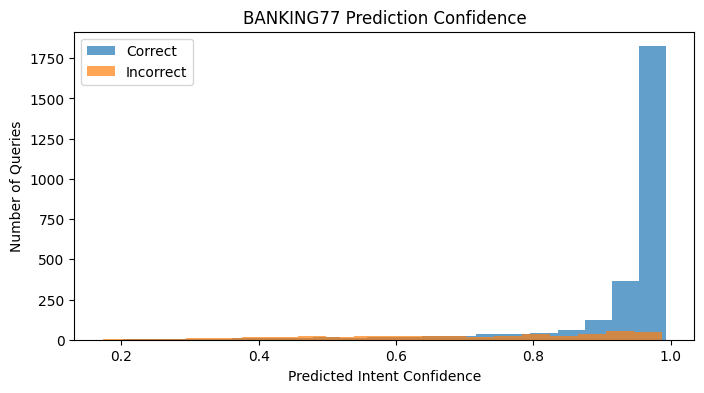

In [15]:
probabilities = torch.softmax(
    torch.tensor(test_output.predictions),
    dim=-1
).numpy()

predicted_confidence = probabilities[
    np.arange(len(test_predictions)),
    test_predictions
]

correct_mask = test_predictions == test_labels_final

print(f"Mean Confidence - Correct: {predicted_confidence[correct_mask].mean():.4f}")
if np.any(~correct_mask):
    print(f"Mean Confidence - Incorrect: {predicted_confidence[~correct_mask].mean():.4f}")

plt.figure(figsize=(8, 4))
plt.hist(predicted_confidence[correct_mask], bins=20, alpha=0.7, label="Correct")
if np.any(~correct_mask):
    plt.hist(predicted_confidence[~correct_mask], bins=20, alpha=0.7, label="Incorrect")
plt.xlabel("Predicted Intent Confidence")
plt.ylabel("Number of Queries")
plt.title("BANKING77 Prediction Confidence")
plt.legend()
plt.show()

## 16. Representative Error Analysis

Inspect representative misclassified queries and their strongest alternative intents.

In [16]:
misclassified_indices = np.where(
    test_predictions != test_labels_final
)[0]

print("Misclassified Test Queries:", len(misclassified_indices))

for index in misclassified_indices[:15]:
    row = probabilities[index]
    top_indices = np.argsort(row)[-3:][::-1]

    print("=" * 110)
    print("Query:", test_texts[index])
    print("True Intent:", class_names[test_labels_final[index]])
    print("Predicted Intent:", class_names[test_predictions[index]])
    print("Top Predictions:")

    for class_id in top_indices:
        print(f"  {class_names[class_id]}: {row[class_id]:.4f}")

Misclassified Test Queries: 442
Query: How do I locate my card?
True Intent: card_arrival
Predicted Intent: lost_or_stolen_card
Top Predictions:
  lost_or_stolen_card: 0.2986
  card_linking: 0.2604
  activate_my_card: 0.1380
Query: Is there a way to know when my card will arrive?
True Intent: card_arrival
Predicted Intent: card_delivery_estimate
Top Predictions:
  card_delivery_estimate: 0.4849
  card_arrival: 0.4449
  activate_my_card: 0.0096
Query: When will I get my card?
True Intent: card_arrival
Predicted Intent: order_physical_card
Top Predictions:
  order_physical_card: 0.8580
  card_delivery_estimate: 0.0729
  visa_or_mastercard: 0.0076
Query: i have not received my card
True Intent: card_arrival
Predicted Intent: order_physical_card
Top Predictions:
  order_physical_card: 0.6467
  card_delivery_estimate: 0.2288
  card_arrival: 0.0344
Query: How long does a card delivery take?
True Intent: card_arrival
Predicted Intent: card_delivery_estimate
Top Predictions:
  card_delivery_es

## 17. Interactive Intent Prediction

Run custom banking queries through the fine-tuned classifier.

In [17]:
def predict_intent(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )

    device = next(model.parameters()).device

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    ).cpu().numpy()[0]

    predicted_class = int(
        np.argmax(probabilities)
    )

    print("Query:", text)
    print(
        "Predicted Intent:",
        class_names[predicted_class]
    )
    print(
        "Confidence:",
        f"{probabilities[predicted_class]:.4f}"
    )

    print()
    print("Top Intent Predictions:")

    top_indices = np.argsort(
        probabilities
    )[-5:][::-1]

    for class_id in top_indices:
        print(
            f"{class_names[class_id]:<40}"
            f"{probabilities[class_id]:.4f}"
        )


examples = [
    "Where is my card?",
    "I do not recognize this cash withdrawal",
    "Why is my transfer still pending?",
    "I need to change my PIN"
]

for example in examples:
    predict_intent(example)
    print("=" * 90)

Query: Where is my card?
Predicted Intent: card_arrival
Confidence: 0.3008

Top Intent Predictions:
card_arrival                            0.3008
card_acceptance                         0.2417
card_delivery_estimate                  0.1567
order_physical_card                     0.0697
visa_or_mastercard                      0.0571
Query: I do not recognize this cash withdrawal
Predicted Intent: cash_withdrawal_not_recognised
Confidence: 0.9878

Top Intent Predictions:
cash_withdrawal_not_recognised          0.9878
pending_cash_withdrawal                 0.0016
wrong_amount_of_cash_received           0.0014
wrong_exchange_rate_for_cash_withdrawal 0.0011
card_payment_not_recognised             0.0007
Query: Why is my transfer still pending?
Predicted Intent: pending_transfer
Confidence: 0.9627

Top Intent Predictions:
pending_transfer                        0.9627
transfer_timing                         0.0057
balance_not_updated_after_bank_transfer 0.0039
pending_card_payment         

# 18. Key Findings

- The fine-tuned `roberta-base` model achieved a **test accuracy of 85.65%** on the BANKING77 test set.
- The model achieved a **macro F1-score of 0.8562** and a **weighted F1-score of 0.8562**, indicating that overall performance was balanced across the 77 intent classes rather than being driven primarily by the more frequent intents.
- The best validation checkpoint was obtained at **Epoch 14**, with **86.61% validation accuracy** and **0.8688 validation macro F1**.
- Training continued beyond the best checkpoint, but the validation metrics stopped improving consistently. Restoring the best checkpoint therefore provided a more reliable model for final evaluation.
- The final test evaluation produced **442 misclassified queries out of 3,080 test examples**.
- The remaining errors were concentrated around semantically similar banking intents. Examples included confusion between `card_arrival` and `card_delivery_estimate`, as well as other closely related card, payment, and transfer intents.
- Some ambiguous queries produced relatively close probability distributions across several plausible intents. For example, queries concerning card delivery could receive substantial probability for multiple card-related categories.
- Prediction confidence was substantially higher for correct predictions than incorrect predictions. The mean confidence was **0.9326 for correct predictions** compared with **0.7010 for incorrect predictions**, indicating that many difficult examples were associated with lower model confidence.
- The results show that pretrained RoBERTa can distinguish a large number of fine-grained banking intents effectively, while the remaining errors primarily arise from subtle semantic differences between closely related categories.

# 19. Conclusion

The RoBERTa-based intent classifier successfully learned to classify natural-language banking queries across the 77 BANKING77 intent categories. The final model achieved **85.65% test accuracy**, with both macro and weighted F1 reaching **0.8562**.

The validation results showed that the model reached its strongest generalization performance at **Epoch 14**, after which additional training did not produce a consistent improvement. Selecting the best validation checkpoint therefore helped prevent the final model from being determined by a later, weaker training state.

The class-level and confusion analyses showed that the main challenge was not broad topic recognition but distinguishing between closely related banking intents. Queries concerning card delivery, transfers, payments, and other related operations can share substantial vocabulary while representing different customer-service actions.

Confidence analysis also showed that incorrect predictions were generally less confident than correct predictions, although some ambiguous queries still received substantial confidence. This suggests that confidence can provide a useful signal for identifying cases that may require additional handling.

Overall, the experiment demonstrates that a pretrained RoBERTa model can provide a strong baseline for fine-grained banking intent classification while also revealing the importance of detailed per-intent evaluation and error analysis for closely related customer-service categories.